# GSoC 2026 | ML4Sci EXXA | Image Test
## Planet-Focused Ring-Aware VAE for Protoplanetary Disk Reconstruction

**Candidate:** Divyansh Soni

---

### Pipeline Overview

```
FITS Files → Preprocessing (arcsinh stretch · star mask · normalize)
           → Attention Map Computation (clean map + pointness map)
           → DiskVAE Training (attention-weighted loss · planet head · joint augmentation)
           → Evaluation (MSE · MS-SSIM · per-image viewer)
           → Inference API (encode · run_inference)
```

![image_task/diskvae_full_architecture3.svg](diskvae_full_architecture3.svg)

## 1. Imports & Device Setup

All dependencies loaded upfront. `pytorch-msssim` provides the MS-SSIM metric required by the task specification. Device is set to GPU if available.

In [10]:
import os
import csv
import math
import numpy as np
from scipy.ndimage import (gaussian_filter, median_filter, gaussian_laplace,
                            label, uniform_filter, center_of_mass)
from astropy.io import fits
from skimage.feature import peak_local_max
from sklearn.model_selection import train_test_split
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import umap
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from pytorch_msssim import SSIM, ms_ssim
from ipywidgets import interact, widgets
import matplotlib.pyplot as plt
from tqdm import tqdm

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. Configuration

All hyperparameters in one place. Set `TRAIN_FROM_SCRATCH = True` to retrain, `False` to load the pre-trained checkpoint and run inference directly.

In [ ]:
TRAIN_FROM_SCRATCH = False          # set True to retrain from scratch

# Data
DATA_PATH          = "../continuum_data_subset"
CHECKPOINT_PATH    = "task2.pth"
TEST_SIZE          = 0.2
RANDOM_SEED        = 42

# Architecture
LATENT_DIM         = 128

# Training
EPOCHS             = 800
BATCH_SIZE         = 16
LR                 = 3e-4
WEIGHT_DECAY       = 1e-5
ES_PATIENCE        = 100
ES_MIN_DELTA       = 1e-4
BETA_KL_MAX        = 1e-3
BETA_WARMUP_EPOCHS = 100

# Loss weights
ALPHA_CLEAN        = 1000.0   # attention boost for ring structure regions
ALPHA_PLANET       = 5000.0   # attention boost for planet candidate regions
ALPHA_HEAD         = 5.0      # planet head loss multiplier

## 3. Data Discovery & Split

I recursively collect all FITS files from the dataset directory and split them 80/20 into train and test sets with a fixed seed. The split is fixed for the entire pipeline — all downstream blocks use `files_train` and `files_test` exclusively.

In [12]:
data_path="../continuum_data_subset"
files=[]

for root,dirs,fs in os.walk(data_path):
    for f in fs:
        if f.endswith(".fits"):
            files.append(os.path.join(root,f))

print(f"Total FITS files found: {len(files)}")

files_train,files_test=train_test_split(files,test_size=0.2,random_state=42,shuffle=True)

print(f"Train : {len(files_train)} files")
print(f"Test  : {len(files_test)} files")

Total FITS files found: 150
Train : 120 files
Test  : 30 files


## 4. Preprocessing

Raw FITS frames go through a minimal pipeline designed to correct only unavoidable acquisition artefacts while preserving disk morphology:

- **NaN and Inf removal** — replaces invalid values with zero
- **Arcsinh stretch** — compresses the extreme dynamic range of ALMA flux values and lifts faint ring features that would otherwise be invisible after normalization
- **Central star masking** — replaces the saturated star core with the local annulus median, preventing the bright center from dominating the loss
- **Normalization** — scales to [0, 1] per image

All images are resized to 128×128 tensors.

Loading train split...


100%|██████████| 120/120 [00:03<00:00, 31.34it/s]


Loading test split...


100%|██████████| 30/30 [00:00<00:00, 32.76it/s]


Train tensor : torch.Size([120, 1, 128, 128])
Test tensor  : torch.Size([30, 1, 128, 128])


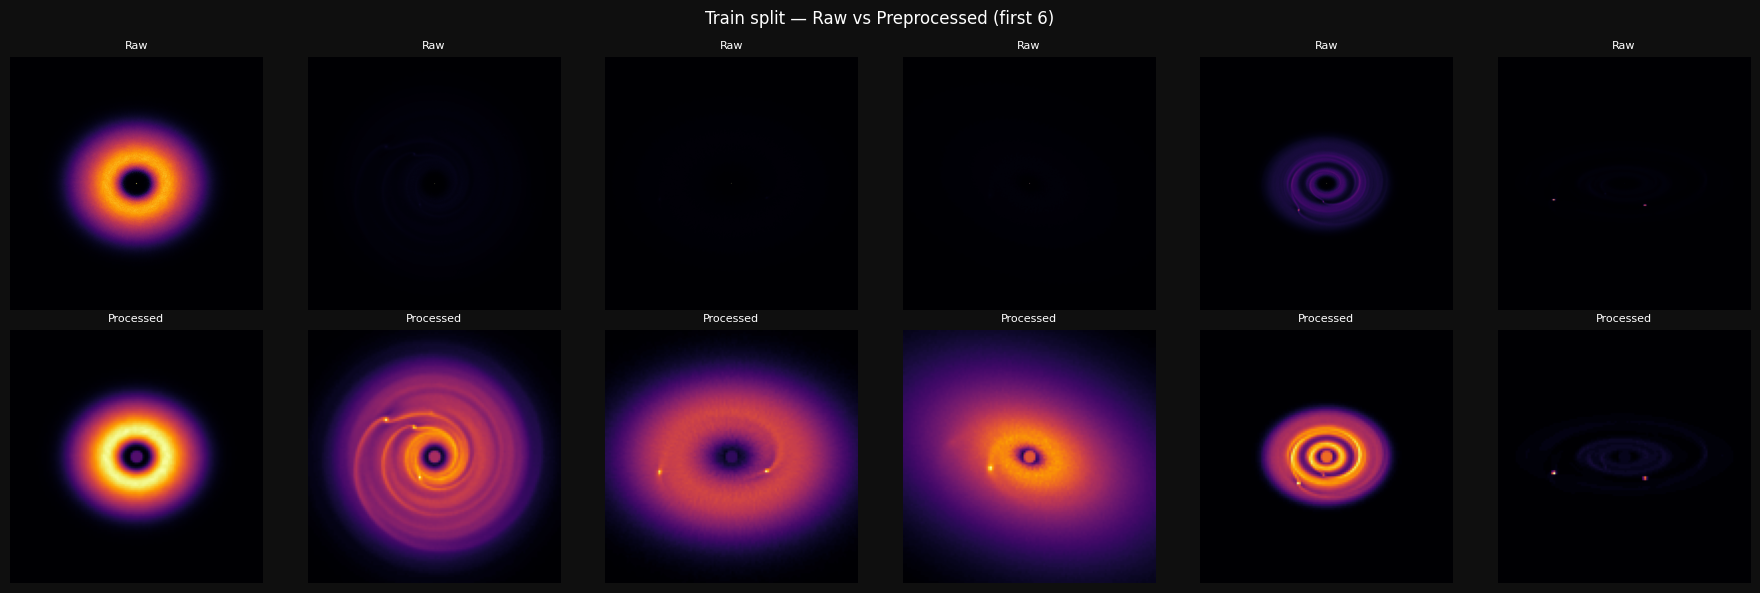

In [24]:
transform=transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

def preprocess_fits(data,mask_radius=15):
    """
    Minimal preprocessing pipeline that preserves disk morphology.
    Corrects only unavoidable acquisition artefacts.

    Steps:
        1. Replace NaNs / Infs with 0
        2. Arcsinh stretch to compress bright rings and lift faint features
        3. Replace central star bleed with local annulus median
        4. Normalize to [0, 1]

    Args:
        data        : 2D numpy float array (raw FITS frame)
        mask_radius : pixel radius of the central star mask

    Returns:
        Preprocessed 2D float32 array
    """
    data=np.nan_to_num(data,nan=0.0,posinf=0.0,neginf=0.0)
    h,w=data.shape
    cx,cy=h//2,w//2
    data=np.arcsinh(5*(data-np.min(data)))
    y,x=np.ogrid[:h,:w]
    dist=np.sqrt((x-cx)**2+(y-cy)**2)
    star_mask=dist<mask_radius
    data[star_mask]=np.median(data[(dist>=mask_radius)&(dist<mask_radius*3)])
    data=data-np.min(data)
    if data.max()>0:
        data/=data.max()
    return data.astype(np.float32)

def load_fits_split(file_list):
    """Loads and preprocesses a list of FITS files into tensors."""
    raw_imgs,imgs,nms=[],[],[]
    for path in tqdm(file_list):
        try:
            with fits.open(path) as hdul:
                data=hdul[0].data
                while data.ndim>2:
                    data=data[0]
                raw=np.nan_to_num(data).astype(np.float32)
                raw_imgs.append(raw)
                imgs.append(transform(preprocess_fits(raw)))
                nms.append(os.path.basename(path))
        except Exception as e:
            print(f"Error loading {path}: {e}")
    return raw_imgs,torch.stack(imgs),nms

print("Loading train split...")
raw_images_train,images_train,names_train=load_fits_split(files_train)
print("Loading test split...")
raw_images_test,images_test,names_test=load_fits_split(files_test)
print(f"Train tensor : {images_train.shape}")
print(f"Test tensor  : {images_test.shape}")

fig,axes=plt.subplots(2,6,figsize=(18,6))
for i in range(6):
    axes[0,i].imshow(raw_images_train[i],cmap='inferno')
    axes[0,i].set_title('Raw',color='white',fontsize=8)
    axes[0,i].axis('off')
    axes[1,i].imshow(images_train[i].squeeze().cpu().numpy(),cmap='inferno')
    axes[1,i].set_title('Processed',color='white',fontsize=8)
    axes[1,i].axis('off')
fig.patch.set_facecolor('#0f0f0f')
plt.suptitle("Train split — Raw vs Preprocessed (first 6)",color='white',fontsize=12)
plt.tight_layout()
plt.show()

## 5. Model :VAE

Standard autoencoders treat disk images like natural images with no awareness of the underlying physical structure. I built DiskVAE specifically around the geometry of protoplanetary disks.

**Radial conditioning**
I inject a normalized radial distance map as a second input channel at every encoder and decoder stage. The model always knows how far each pixel is from the disk center, anchoring ring-aware features throughout the network rather than having to infer geometry from pixel values alone.

**Bottleneck self-attention**
I added self-attention at the 4×4 bottleneck so the model enforces global ring coherence. A ring on one side of the disk should be consistent with the opposite side , local convolutions cannot capture this, but attention at the bottleneck can.

**U-Net skip connections**
Compression through the bottleneck loses fine ring detail. Skip connections bring encoder features directly into the decoder so thin rings and gap edges survive the round trip.

**Planet head (jointly trained)**
I attached a planet detection head to the bottleneck and trained it jointly with reconstruction from epoch 1. This shapes the latent space around both objectives from the start rather than retrofitting detection afterward as a separate stage.

**Accessible latent space**
The posterior mean μ serves as the deterministic 128-dimensional latent vector for each image. `encode()` and `run_inference()` expose this directly.

![image_task/diskvae_task2-1.svg](diskvae_task2_archi.svg)

In [25]:
class RadialAttention(nn.Module):
    """
    Lightweight self-attention at the 4×4 bottleneck.
    Enforces global ring coherence at low compute cost.

    Args:
        channels : number of input/output feature channels
    """
    def __init__(self,channels):
        super().__init__()
        self.qkv=nn.Conv2d(channels,channels*3,1)
        self.proj=nn.Conv2d(channels,channels,1)
        self.norm=nn.GroupNorm(8,channels)
        self.scale=channels**-0.5

    def forward(self,x):
        B,C,H,W=x.shape
        qkv=self.qkv(self.norm(x)).reshape(B,3,C,H*W)
        q,k,v=qkv[:,0],qkv[:,1],qkv[:,2]
        attn=(q.transpose(-2,-1)@k)*self.scale
        attn=attn.softmax(dim=-1)
        out=(v@attn).reshape(B,C,H,W)
        return x+self.proj(out)


class ResBlock(nn.Module):
    """
    Residual block with GroupNorm and LeakyReLU for stable deep training.

    Args:
        channels : number of input/output feature channels
    """
    def __init__(self,channels):
        super().__init__()
        self.block=nn.Sequential(
            nn.GroupNorm(8,channels),
            nn.LeakyReLU(0.2),
            nn.Conv2d(channels,channels,3,padding=1),
            nn.GroupNorm(8,channels),
            nn.LeakyReLU(0.2),
            nn.Conv2d(channels,channels,3,padding=1),
        )

    def forward(self,x):
        return x+self.block(x)


class DiskVAE(nn.Module):
    """
    Ring-aware Variational Autoencoder for protoplanetary disk images.

    Combines U-Net skip connections, multi-scale radial conditioning, and
    bottleneck self-attention to learn structured latent representations
    that respect disk radial geometry.

    Args:
        latent_dim : dimensionality of the latent space (default: 128)
    """
    def __init__(self,latent_dim=128):
        super().__init__()
        self.enc1=nn.Sequential(nn.Conv2d(2,48,4,2,1),nn.LeakyReLU(0.2))
        self.enc2=nn.Sequential(nn.Conv2d(48,96,4,2,1),nn.GroupNorm(8,96),nn.LeakyReLU(0.2),ResBlock(96))
        self.enc3=nn.Sequential(nn.Conv2d(96,192,4,2,1),nn.GroupNorm(8,192),nn.LeakyReLU(0.2),ResBlock(192))
        self.enc4=nn.Sequential(nn.Conv2d(192,256,4,2,1),nn.GroupNorm(8,256),nn.LeakyReLU(0.2),ResBlock(256))
        self.enc5=nn.Sequential(nn.Conv2d(256,256,4,2,1),nn.LeakyReLU(0.2))
        self.bottleneck_attn=RadialAttention(256)
        self.fc_mu=nn.Linear(256*4*4,latent_dim)
        self.fc_logvar=nn.Linear(256*4*4,latent_dim)
        self.fc_decode=nn.Linear(latent_dim,256*4*4)
        self.dec5=nn.Sequential(nn.ConvTranspose2d(257,256,4,2,1),nn.LeakyReLU(0.2))
        self.dec4=nn.Sequential(nn.ConvTranspose2d(513,192,4,2,1),nn.GroupNorm(8,192),nn.LeakyReLU(0.2),ResBlock(192))
        self.dec3=nn.Sequential(nn.ConvTranspose2d(385,128,4,2,1),nn.GroupNorm(8,128),nn.LeakyReLU(0.2),ResBlock(128))
        self.dec2=nn.Sequential(nn.ConvTranspose2d(225,64,4,2,1),nn.GroupNorm(8,64),nn.LeakyReLU(0.2))
        self.dec1=nn.Sequential(
            nn.ConvTranspose2d(113,32,4,2,1),nn.LeakyReLU(0.2),
            nn.Conv2d(32,1,3,padding=1),nn.Sigmoid()
        )
        self.planet_head=nn.Sequential(
            nn.Conv2d(256,64,3,padding=1),nn.ReLU(),
            nn.Conv2d(64,1,1),nn.Sigmoid(),
            nn.Upsample(size=(128,128),mode='bilinear',align_corners=False)
        )
        self._radial_cache={}

    def _get_radial_map(self,B,H,W,device):
        key=(H,W,device)
        if key not in self._radial_cache:
            cy,cx=H/2.0,W/2.0
            yy=torch.arange(H,device=device,dtype=torch.float32)-cy
            xx=torch.arange(W,device=device,dtype=torch.float32)-cx
            grid_y,grid_x=torch.meshgrid(yy,xx,indexing='ij')
            r=torch.sqrt(grid_x**2+grid_y**2)
            r=r/(r.max()+1e-8)
            self._radial_cache[key]=r.unsqueeze(0).unsqueeze(0)
        return self._radial_cache[key].expand(B,1,H,W)

    def reparameterize(self,mu,logvar):
        std=torch.exp(0.5*logvar)
        return mu+std*torch.randn_like(std)

    def forward(self,x):
        B,C,H,W=x.shape
        radial=self._get_radial_map(B,H,W,x.device)
        s1=self.enc1(torch.cat([x,radial],dim=1))
        s2=self.enc2(s1)
        s3=self.enc3(s2)
        s4=self.enc4(s3)
        s5=self.enc5(s4)
        feat=self.bottleneck_attn(s5)
        mu,logvar=self.fc_mu(feat.view(B,-1)),self.fc_logvar(feat.view(B,-1))
        z=self.reparameterize(mu,logvar)
        d=self.fc_decode(z).view(B,256,4,4)
        d=self.dec5(torch.cat([d,F.interpolate(radial,(4,4),mode='bilinear',align_corners=False)],dim=1))
        d=self.dec4(torch.cat([d,s4,F.interpolate(radial,(8,8),mode='bilinear',align_corners=False)],dim=1))
        d=self.dec3(torch.cat([d,s3,F.interpolate(radial,(16,16),mode='bilinear',align_corners=False)],dim=1))
        d=self.dec2(torch.cat([d,s2,F.interpolate(radial,(32,32),mode='bilinear',align_corners=False)],dim=1))
        recon=self.dec1(torch.cat([d,s1,F.interpolate(radial,(64,64),mode='bilinear',align_corners=False)],dim=1))
        return recon,mu,logvar,self.planet_head(feat)

## 6. Loss Functions & Training Utilities

MSE alone produces blurry reconstructions that average out the thin bright rings that are scientifically important. I designed a set of domain-specific losses to address this.

**`azimuthal_smoothness_loss`**
Disks are physically near-symmetric around their center. I explicitly penalize azimuthal variation ring by ring, enforcing this prior directly in the loss rather than hoping the model discovers it.

**`radial_profile_loss`**
The radial brightness profile is the primary observable in disk science. I match it explicitly at every radial bin rather than relying on pixel-wise loss to capture it incidentally.

**`gradient_loss`**
Preserves the sharp edges at ring boundaries that MSE and SSIM both tend to blur.

**`build_clean_and_pointness`**
The model had no way to know which pixels mattered , background dominates most of the image. I precompute a clean map (large-scale background subtracted to reveal ring structure) and a pointness map (Laplacian of Gaussian at two scales multiplied by local peakiness) for every image before training. These are fixed per-image maps used as attention weights every epoch.

**`build_planet_loss_mask`**
Not every high pointness pixel is a real planet candidate,  noise triggers the LoG too. I filter by brightness and compactness so only pixels that are both bright enough and locally concentrated activate the planet head loss.

**`apply_joint_augmentation`**
Standard augmentation only transforms the image. Since the attention weights are spatial maps, rotating or flipping the image without doing the same to the clean and pointness maps misaligns them , the model gets told to focus on the wrong pixels. I apply the identical affine transform to all three together.

**`BetaScheduler`**
Full KL divergence from epoch 0 collapses the latent space before the decoder learns anything useful. I warm it up linearly over 100 epochs so reconstruction quality is established first.

**`EarlyStopping`**
With a small dataset the model overfits well before 800 epochs. I set patience to 100 to give enough room for the loss to plateau and recover before stopping.

In [26]:
def tv_loss(x):
    """Total variation loss — penalizes spurious high-frequency noise."""
    dx=(x[:,:,:,1:]-x[:,:,:,:-1]).abs().mean()
    dy=(x[:,:,1:,:]-x[:,:,:-1,:]).abs().mean()
    return dx+dy

def multiscale_l1(pred,target,scales=(1,2,4)):
    """L1 loss averaged across spatial scales for global structure consistency."""
    loss=0.0
    for s in scales:
        p=F.avg_pool2d(pred,kernel_size=s,stride=s) if s>1 else pred
        t=F.avg_pool2d(target,kernel_size=s,stride=s) if s>1 else target
        loss=loss+F.l1_loss(p,t)
    return loss/len(scales)

def ssim_loss(pred,target,window_size=7):
    """Structural Similarity loss — captures ring structure and local contrast."""
    C1,C2=0.01**2,0.03**2
    pad=window_size//2
    mu_p=F.avg_pool2d(pred,window_size,stride=1,padding=pad)
    mu_t=F.avg_pool2d(target,window_size,stride=1,padding=pad)
    mu_p2,mu_t2,mu_pt=mu_p*mu_p,mu_t*mu_t,mu_p*mu_t
    sigma_p2=F.avg_pool2d(pred*pred,window_size,stride=1,padding=pad)-mu_p2
    sigma_t2=F.avg_pool2d(target*target,window_size,stride=1,padding=pad)-mu_t2
    sigma_pt=F.avg_pool2d(pred*target,window_size,stride=1,padding=pad)-mu_pt
    ssim_map=((2*mu_pt+C1)*(2*sigma_pt+C2))/((mu_p2+mu_t2+C1)*(sigma_p2+sigma_t2+C2))
    return 1.0-ssim_map.mean()

def gradient_loss(recon,target):
    """Gradient matching loss — preserves sharp ring edges."""
    gy_r,gx_r=torch.gradient(recon.squeeze(1),dim=[-2,-1])
    gy_t,gx_t=torch.gradient(target.squeeze(1),dim=[-2,-1])
    return F.mse_loss(gx_r,gx_t)+F.mse_loss(gy_r,gy_t)

def azimuthal_smoothness_loss(recon,center_mask_r=8):
    """Penalizes azimuthal variation per radial ring."""
    B,C,H,W=recon.shape
    cy,cx=H/2.0,W/2.0
    yy=torch.arange(H,device=recon.device,dtype=torch.float32)-cy
    xx=torch.arange(W,device=recon.device,dtype=torch.float32)-cx
    gy,gx=torch.meshgrid(yy,xx,indexing='ij')
    r_map=torch.sqrt(gx**2+gy**2).long()
    r_max=int(min(cx,cy))
    loss,count=torch.tensor(0.0,device=recon.device),0
    for ri in range(center_mask_r,r_max-2,2):
        mask=(r_map==ri)
        if mask.sum()<8:continue
        loss=loss+recon[:,:,mask].var(dim=-1).mean()
        count+=1
    return loss/max(count,1)

def radial_profile_loss(recon,target,center_mask_r=3):
    """Forces reconstructed radial brightness profile to match the target."""
    B,C,H,W=recon.shape
    cy,cx=H/2.0,W/2.0
    yy=torch.arange(H,device=recon.device,dtype=torch.float32)-cy
    xx=torch.arange(W,device=recon.device,dtype=torch.float32)-cx
    gy,gx=torch.meshgrid(yy,xx,indexing='ij')
    r_map=torch.sqrt(gx**2+gy**2).long()
    r_max=int(min(cx,cy))
    loss,count=torch.tensor(0.0,device=recon.device),0
    for ri in range(center_mask_r,r_max-1):
        mask=(r_map==ri)
        if mask.sum()<4:continue
        loss=loss+F.l1_loss(recon[:,:,mask].mean(dim=-1),target[:,:,mask].mean(dim=-1))
        count+=1
    return loss/max(count,1)

def build_clean_and_pointness(image_tensor,sigma_factor=2.5,fwhm=3.0,edge_mask=14):
    """
    Computes background-subtracted clean map and LoG pointness map from a
    single preprocessed image. Precomputed once and cached as attention weights.

    Returns:
        clean     : (1, H, W) float tensor — structural disk features
        pointness : (1, H, W) float tensor — planet candidate map
    """
    r=image_tensor.squeeze().numpy().astype(np.float32)
    h,w=r.shape
    sigma=fwhm/2.355
    valid=np.ones((h,w),dtype=bool)
    valid[:edge_mask,:]=False
    valid[-edge_mask:,:]=False
    valid[:,:edge_mask]=False
    valid[:,-edge_mask:]=False
    smooth=gaussian_filter(r,sigma=sigma_factor*sigma)
    clean=np.clip(r-smooth,0,None)
    clean=np.clip(clean-median_filter(clean,size=5),0,None)
    clean[~valid]=0
    mn,mx=clean.min(),clean.max()
    clean=(clean-mn)/(mx-mn+1e-8)
    log1=np.clip(-gaussian_laplace(clean,sigma=sigma)*sigma**2,0,None)
    log2=np.clip(-gaussian_laplace(clean,sigma=1.6*sigma)*(1.6*sigma)**2,0,None)
    peakiness=np.clip(clean-gaussian_filter(clean,sigma=2.2*sigma),0,None)
    pointness=np.minimum(log1,log2)*peakiness
    mn,mx=pointness.min(),pointness.max()
    pointness=(pointness-mn)/(mx-mn+1e-8)
    pointness[~valid]=0
    return (torch.from_numpy(clean).unsqueeze(0).float(),
            torch.from_numpy(pointness).unsqueeze(0).float())

def build_planet_loss_mask(pointness_map,faint_thr=0.02,compactness_thr=0.19,patch_r=8):
    """
    Pixel-wise mask consistent with detection thresholds.
    Only pixels passing faint and compactness filters are active.
    """
    faint_mask=(pointness_map>faint_thr).float()
    kernel_size=patch_r*2+1
    patch_sum=F.avg_pool2d(pointness_map,kernel_size=kernel_size,
                            stride=1,padding=patch_r)*kernel_size**2
    compactness=pointness_map/(patch_sum+1e-8)
    compact_mask=(compactness>compactness_thr).float()
    return faint_mask*compact_mask

def apply_joint_augmentation(batch,c_maps,pt_maps):
    """
    Applies identical spatial augmentation to the image batch and both
    attention maps so they remain spatially aligned after transformation.
    Flux jitter is applied to the image only.
    """
    B,C,H,W=batch.shape
    device=batch.device
    with torch.no_grad():
        if torch.rand(1)<0.5:
            batch=torch.flip(batch,[-1])
            c_maps=torch.flip(c_maps,[-1])
            pt_maps=torch.flip(pt_maps,[-1])
        if torch.rand(1)<0.5:
            batch=torch.flip(batch,[-2])
            c_maps=torch.flip(c_maps,[-2])
            pt_maps=torch.flip(pt_maps,[-2])
        angle=torch.rand(B,device=device)*2*np.pi
        scale=torch.rand(B,device=device)*0.2+0.9
        tx=torch.rand(B,device=device)*0.1-0.05
        ty=torch.rand(B,device=device)*0.1-0.05
        cos_a,sin_a=torch.cos(angle),torch.sin(angle)
        theta=torch.zeros(B,2,3,device=device)
        theta[:,0,0]=cos_a/scale
        theta[:,0,1]=-sin_a/scale
        theta[:,0,2]=tx
        theta[:,1,0]=sin_a/scale
        theta[:,1,1]=cos_a/scale
        theta[:,1,2]=ty
        grid=F.affine_grid(theta,batch.size(),align_corners=False)
        grid_1c=F.affine_grid(theta,c_maps.size(),align_corners=False)
        batch=F.grid_sample(batch,grid,padding_mode='zeros',align_corners=False)
        c_maps=F.grid_sample(c_maps,grid_1c,padding_mode='zeros',align_corners=False)
        pt_maps=F.grid_sample(pt_maps,grid_1c,padding_mode='zeros',align_corners=False)
        batch=batch*(torch.rand(B,1,1,1,device=device)*0.3+0.85)
    return batch,c_maps,pt_maps

class BetaScheduler:
    """Linear warmup schedule for KL divergence weight β."""
    def __init__(self,max_beta,warmup_epochs):
        self.max_beta=max_beta
        self.warmup_epochs=warmup_epochs
    def get_beta(self,epoch):
        if epoch<self.warmup_epochs:
            return self.max_beta*(epoch/self.warmup_epochs)
        return self.max_beta

class EarlyStopping:
    """Stops training when validation loss stops improving."""
    def __init__(self,patience=100,min_delta=1e-4):
        self.patience=patience
        self.min_delta=min_delta
        self.counter=0
        self.best_loss=float('inf')
        self.best_epoch=0
    def step(self,val_loss,epoch):
        if val_loss<self.best_loss-self.min_delta:
            self.best_loss=val_loss
            self.best_epoch=epoch
            self.counter=0
            return False
        self.counter+=1
        return self.counter>=self.patience

ssim_fn=SSIM(data_range=1.0,size_average=True,channel=1)

## 7. Attention Map Precomputation

I build clean and pointness maps for every image in both splits before training begins. These are reused every epoch as fixed per-pixel attention weights , computing them once upfront avoids repeating the expensive LoG computation inside the training loop.

The weight map applied during training is: `1 + 1000 × clean_map + 5000 × pointness_map`

Ring pixels receive 1000× the gradient signal of background pixels, and planet candidate pixels receive 5000×. The model has no choice but to reconstruct them correctly.

In [27]:
print("Building clean + pointness maps (train)...")
clean_train_list,pointness_train_list=[],[]
for i in tqdm(range(len(images_train))):
    c,p=build_clean_and_pointness(images_train[i])
    clean_train_list.append(c)
    pointness_train_list.append(p)
clean_maps_train=torch.stack(clean_train_list)
pointness_maps_train=torch.stack(pointness_train_list)

print("Building clean + pointness maps (test)...")
clean_test_list,pointness_test_list=[],[]
for i in tqdm(range(len(images_test))):
    c,p=build_clean_and_pointness(images_test[i])
    clean_test_list.append(c)
    pointness_test_list.append(p)
clean_maps_test=torch.stack(clean_test_list)
pointness_maps_test=torch.stack(pointness_test_list)

print(f"Train — clean: {clean_maps_train.shape} | pointness: {pointness_maps_train.shape}")
print(f"Test  — clean: {clean_maps_test.shape}  | pointness: {pointness_maps_test.shape}")

Building clean + pointness maps (train)...


100%|██████████| 120/120 [00:00<00:00, 289.08it/s]


Building clean + pointness maps (test)...


100%|██████████| 30/30 [00:00<00:00, 304.16it/s]

Train — clean: torch.Size([120, 1, 128, 128]) | pointness: torch.Size([120, 1, 128, 128])
Test  — clean: torch.Size([30, 1, 128, 128])  | pointness: torch.Size([30, 1, 128, 128])


## 8. Load Checkpoint

Loads pre-trained weights from disk. If `TRAIN_FROM_SCRATCH` is set to `True` in the config, skip this cell and run the training cell instead. If the checkpoint is not found, training must be run first.

In [ ]:
checkpoint_path = 'task2.pth'

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=True)
    model      = DiskVAE(latent_dim=checkpoint['latent_dim']).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    print(f"Loaded DiskVAE from '{checkpoint_path}' — {checkpoint['epoch']} epochs trained")
else:
    print(f"No checkpoint found at '{checkpoint_path}' — run the training block first")

Loaded DiskVAE from '../task2.pth' — 539 epochs trained


## 9. Training - Unified Weighted Objective

The core problem with a standard autoencoder on disk images is that most pixels are empty background. A model minimizing average pixel loss correctly reconstructs background and largely ignores the faint rings and planet candidates that are scientifically relevant.

**Difference from the general test**
In the general test I trained the VAE with a blurred reconstruction target , the goal was smooth background structure recovery so that planets would surface cleanly in the residual. Here I reconstruct the real image directly and replaced the uniform pixel loss with an attention-weighted objective. The model is no longer trying to recover a smoothed version of the disk; it is trying to recover the actual observation with explicit pressure on the regions that matter scientifically. The planet head is also trained jointly here from epoch 1 rather than being derived from residuals after training.

**Attention-weighted loss**
The per-pixel weight map `1 + 1000×clean + 5000×pointness` is applied directly to the reconstruction loss. Ring and planet pixels dominate the gradient signal.

**Joint augmentation**
Image and attention maps are transformed together so spatial transforms never misalign the attention weights from the pixels they correspond to.

**Loss terms**

| Term | Weight |
|---|---|
| Weighted pixel L1 | 1.0 |
| SSIM | 0.80 |
| Multiscale L1 | 0.50 |
| Gradient loss | 0.25 |
| Total variation | 0.02 |
| Azimuthal smoothness | 0.50 |
| Radial profile | 0.30 |
| Planet head | ALPHA_HEAD × |
| KL divergence | β × (warmed up) |


In [29]:
if TRAIN_FROM_SCRATCH:
    ALPHA_CLEAN=1000.0
    ALPHA_PLANET=5000.0
    ALPHA_HEAD=5.0
    BETA_KL=1e-3
    
    model=DiskVAE(latent_dim=128).to(device)
    optimizer=torch.optim.AdamW(model.parameters(),lr=3e-4,weight_decay=1e-5)
    beta_scheduler=BetaScheduler(max_beta=BETA_KL,warmup_epochs=100)
    early_stopping=EarlyStopping(patience=100,min_delta=1e-4)
    epochs,batch_size=800,32
    scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=epochs,eta_min=1e-6)
    best_state=None
    history={
        'train':[],'val':[],'val_ssim':[],
        'train_recon':[],'train_planet':[],'train_kl':[],
        'val_recon':[],'val_planet':[],'val_kl':[],
    }
    
    print(f"Training on {len(images_train)} images, validating on {len(images_test)} images")
    pbar=tqdm(range(epochs),desc="Training")
    
    for epoch in pbar:
        model.train()
        perm=torch.randperm(len(images_train))
        beta=beta_scheduler.get_beta(epoch)
        totals={'total':0.,'recon':0.,'planet':0.,'kl':0.}
    
        for i in range(0,len(images_train),batch_size):
            idx=perm[i:i+batch_size]
            clean_batch=images_train[idx].to(device)
            c_maps=clean_maps_train[idx].to(device)
            pt_maps=pointness_maps_train[idx].to(device)
            batch,c_maps,pt_maps=apply_joint_augmentation(clean_batch,c_maps,pt_maps)
            recon,mu,logvar,planet_map=model(batch)
            weights=1.0+ALPHA_CLEAN*c_maps+ALPHA_PLANET*pt_maps
            pixel_loss=(torch.abs(recon-batch)*weights).mean()
            ssim=ssim_loss(recon,batch)
            ms_loss=multiscale_l1(recon,batch)
            grad=gradient_loss(recon,batch)
            smooth=tv_loss(recon)
            az_smooth=azimuthal_smoothness_loss(recon)
            rad_prof=radial_profile_loss(recon,batch)
            p_mask=build_planet_loss_mask(pt_maps)
            p_pixels=p_mask.sum().clamp(min=1)
            planet_l=((planet_map-pt_maps)**2*p_mask).sum()/p_pixels
            kl_l=-0.5*torch.mean(1+logvar-mu.pow(2)-logvar.exp())
            loss=(pixel_loss
                  +0.80*ssim
                  +0.50*ms_loss
                  +0.25*grad
                  +0.02*smooth
                  +0.50*az_smooth
                  +0.30*rad_prof
                  +ALPHA_HEAD*planet_l
                  +beta*kl_l)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
            optimizer.step()
            totals['total']+=loss.item()
            totals['recon']+=pixel_loss.item()
            totals['planet']+=planet_l.item()
            totals['kl']+=kl_l.item()
    
        scheduler.step()
        n=len(images_train)
        history['train'].append(totals['total']/n)
        history['train_recon'].append(totals['recon']/n)
        history['train_planet'].append(totals['planet']/n)
        history['train_kl'].append(totals['kl']/n)
    
        model.eval()
        val_t={'total':0.,'recon':0.,'planet':0.,'kl':0.}
        val_recons_epoch=[]
        with torch.no_grad():
            for i in range(0,len(images_test),batch_size):
                batch=images_test[i:i+batch_size].to(device)
                c_maps=clean_maps_test[i:i+batch_size].to(device)
                pt_maps=pointness_maps_test[i:i+batch_size].to(device)
                recon,mu,logvar,planet_map=model(batch)
                weights=1.0+ALPHA_CLEAN*c_maps+ALPHA_PLANET*pt_maps
                pixel_loss=(torch.abs(recon-batch)*weights).mean()
                p_mask=build_planet_loss_mask(pt_maps)
                p_pixels=p_mask.sum().clamp(min=1)
                planet_l=((planet_map-pt_maps)**2*p_mask).sum()/p_pixels
                kl_l=-0.5*torch.mean(1+logvar-mu.pow(2)-logvar.exp())
                total_l=(pixel_loss
                         +0.80*ssim_loss(recon,batch)
                         +0.50*multiscale_l1(recon,batch)
                         +0.25*gradient_loss(recon,batch)
                         +0.02*tv_loss(recon)
                         +0.50*azimuthal_smoothness_loss(recon)
                         +0.30*radial_profile_loss(recon,batch)
                         +ALPHA_HEAD*planet_l
                         +beta*kl_l)
                val_t['total']+=total_l.item()
                val_t['recon']+=pixel_loss.item()
                val_t['planet']+=planet_l.item()
                val_t['kl']+=kl_l.item()
                val_recons_epoch.append(recon.cpu())
    
        m=len(images_test)
        history['val'].append(val_t['total']/m)
        history['val_recon'].append(val_t['recon']/m)
        history['val_planet'].append(val_t['planet']/m)
        history['val_kl'].append(val_t['kl']/m)
        val_recons_cat=torch.cat(val_recons_epoch)
        history['val_ssim'].append(ssim_fn(val_recons_cat,images_test).item())
    
        should_stop=early_stopping.step(history['val'][-1],epoch)
        if early_stopping.counter==0:
            best_state={k:v.clone() for k,v in model.state_dict().items()}
    
        pbar.set_description(
            f"Ep {epoch+1} | Train={history['train'][-1]:.4f} | "
            f"Val={history['val'][-1]:.4f} | SSIM={history['val_ssim'][-1]:.4f} | "
            f"Best=Ep{early_stopping.best_epoch+1} | β={beta:.5f}"
        )
        if should_stop:
            print(f"\nEarly stopping at epoch {epoch+1} — best val at epoch {early_stopping.best_epoch+1}")
            break
    
    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"Restored best weights from epoch {early_stopping.best_epoch+1}")
    
    torch.save({
        'epoch':early_stopping.best_epoch+1,
        'latent_dim':128,
        'alpha_clean':ALPHA_CLEAN,
        'alpha_planet':ALPHA_PLANET,
        'alpha_head':ALPHA_HEAD,
        'model_state_dict':model.state_dict(),
        'optimizer_state_dict':optimizer.state_dict(),
        'history':history,
    },'task2.pth')
    print("Checkpoint saved to 'task2.pth'")

## 10. Evaluation & Metrics

I run inference on the held-out test split and report MSE and MS-SSIM as required by the task specification. MS-SSIM uses `win_size=7` to satisfy the minimum image size constraint at 128×128. The training curve plots break down val loss by component so any divergence between reconstruction quality and planet head performance is immediately visible.

In [30]:
if not TRAIN_FROM_SCRATCH:
    ckpt=torch.load(CHECKPOINT_PATH,map_location=device)
    history=ckpt.get('history',None)
    early_stopping=EarlyStopping(patience=ES_PATIENCE,min_delta=ES_MIN_DELTA)
    early_stopping.best_epoch=ckpt.get('epoch',0)-1

C:\Users\divya\AppData\Local\Temp\ipykernel_55004\507257345.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt=torch.load(CHECKPOINT_PATH,map_location=device)



── Test Set Metrics ──────────────────────
MSE     : 0.000036
MS-SSIM : 0.9989
SSIM    : 0.9925


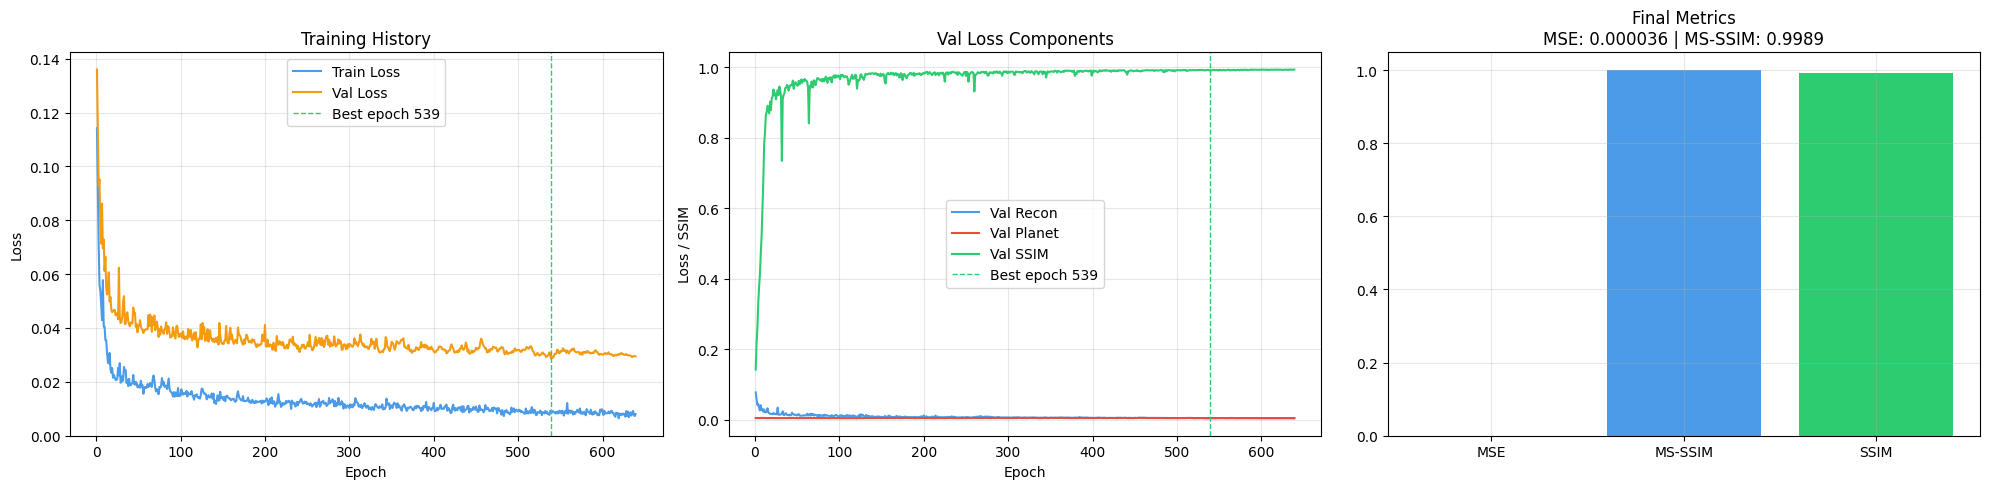

In [31]:
model.eval()
test_recons,test_planet_maps=[],[]
with torch.no_grad():
    for batch in torch.split(images_test.to(device),32):
        recon,_,_,planet_map=model(batch)
        test_recons.append(recon.cpu())
        test_planet_maps.append(planet_map.cpu())

test_recons=torch.cat(test_recons)
test_planet_maps=torch.cat(test_planet_maps)

mse_score=F.mse_loss(test_recons,images_test).item()
msssim_score=ms_ssim(test_recons,images_test,data_range=1.0,win_size=7).item()
ssim_score=ssim_fn(test_recons,images_test).item()

print(f"\n── Test Set Metrics ──────────────────────")
print(f"MSE     : {mse_score:.6f}")
print(f"MS-SSIM : {msssim_score:.4f}")
print(f"SSIM    : {ssim_score:.4f}")

actual_epochs=len(history['train'])
epochs_x=range(1,actual_epochs+1)
if history is not None:
    actual_epochs=len(history['train'])
    epochs_x=range(1,actual_epochs+1)
    fig,axes=plt.subplots(1,3,figsize=(20,5))

    axes[0].plot(epochs_x,history['train'],label='Train Loss',color='#4c9be8',linewidth=1.5)
    axes[0].plot(epochs_x,history['val'],label='Val Loss',color='#f39c12',linewidth=1.5)
    axes[0].axvline(early_stopping.best_epoch+1,color='#2ecc71',linestyle='--',
                    linewidth=1,label=f'Best epoch {early_stopping.best_epoch+1}')
    axes[0].set_title("Training History")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True,alpha=0.3)

    axes[1].plot(epochs_x,history['val_recon'],label='Val Recon',color='#4c9be8',linewidth=1.5)
    axes[1].plot(epochs_x,history['val_planet'],label='Val Planet',color='#e74c3c',linewidth=1.5)
    axes[1].plot(epochs_x,history['val_ssim'],label='Val SSIM',color='#2ecc71',linewidth=1.5)
    axes[1].axvline(early_stopping.best_epoch+1,color='#2ecc71',linestyle='--',
                    linewidth=1,label=f'Best epoch {early_stopping.best_epoch+1}')
    axes[1].set_title("Val Loss Components")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss / SSIM")
    axes[1].legend()
    axes[1].grid(True,alpha=0.3)

    axes[2].bar(['MSE','MS-SSIM','SSIM'],[mse_score,msssim_score,ssim_score],
                color=['#e74c3c','#4c9be8','#2ecc71'])
    axes[2].set_title(f"Final Metrics\nMSE: {mse_score:.6f} | MS-SSIM: {msssim_score:.4f}")
    axes[2].grid(True,alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No training history available — run with TRAIN_FROM_SCRATCH=True to generate plots")

## 11. Interactive Reconstruction Viewer

Browse every test image with a slider. Each panel shows a different view of the same image — input, reconstruction, residual, clean map, pointness map, planet head output, and the attention weight map as used during training. Per-image MSE, MS-SSIM, planet pixel count, and peak planet response are shown in the title.

In [32]:
def reconstruction_viewer(idx=0):
    orig=images_test[idx].squeeze().numpy()
    recon_img=test_recons[idx].squeeze().numpy()
    planet_map=test_planet_maps[idx].squeeze().numpy()
    residual=np.clip(orig-recon_img,0,None)
    clean=clean_maps_test[idx].squeeze().numpy()
    pointness=pointness_maps_test[idx].squeeze().numpy()
    weight_map=1.0+1000.0*clean+5000.0*pointness

    fig,axes=plt.subplots(1,2,figsize=(60,30))
    fig.patch.set_facecolor('#0f0f0f')

    panels=[
        (orig,       "inferno","Input"),
        (recon_img,  "inferno","Reconstruction"),
    ]

    for ax,(data,cmap,title) in zip(axes,panels):
        im=ax.imshow(data,cmap=cmap)
        ax.set_title(title,fontsize=90,color='#cccccc')
        ax.axis('off')
        plt.colorbar(im,ax=ax,fraction=0.046,pad=0.04)
        for spine in ax.spines.values():
            spine.set_visible(False)

    img_mse=F.mse_loss(
        torch.tensor(recon_img).unsqueeze(0).unsqueeze(0),
        torch.tensor(orig).unsqueeze(0).unsqueeze(0)
    ).item()
    img_msssim=ms_ssim(
        torch.tensor(recon_img).unsqueeze(0).unsqueeze(0),
        torch.tensor(orig).unsqueeze(0).unsqueeze(0),
        data_range=1.0,win_size=7
    ).item()
    p_mask=build_planet_loss_mask(
        pointness_maps_test[idx].unsqueeze(0)
    ).squeeze().numpy()
    n_planet_px=int(p_mask.sum())
    peak_planet=float(planet_map.max())

    fig.suptitle(
        f"Test Image [{idx}]  —  {names_test[idx]}  |  "
        f"MSE: {img_mse:.6f}  |  MS-SSIM: {img_msssim:.4f}  |  "
        f"Planet px: {n_planet_px}  |  Peak response: {peak_planet:.3f}",
        fontsize=80,color='white',y=1.02
    )
    plt.tight_layout()
    plt.show()

interact(
    reconstruction_viewer,
    idx=widgets.IntSlider(
        min=0,max=len(images_test)-1,step=1,value=0,
        description="Test ID:",
        style={'description_width':'initial'},
        layout=widgets.Layout(width='500px')
    )
)

interactive(children=(IntSlider(value=0, description='Test ID:', layout=Layout(width='500px'), max=29, style=S…

<function __main__.reconstruction_viewer(idx=0)>

## 12. Latent Space Access & Inference on New Data

`encode()` returns the deterministic latent vector μ for any single image. `run_inference()` loads the checkpoint and processes an entire folder of new FITS files end-to-end, returning reconstructions, latent vectors, and planet maps in one call.

These two functions are the primary entry points for evaluation on withheld data.

In [33]:
def encode(image_tensor,checkpoint=None):
    """
    Encodes a single preprocessed image into the latent space.
    Returns mu (deterministic latent vector), not a stochastic sample.

    Args:
        image_tensor : (1, H, W) or (1, 1, H, W) float tensor
        checkpoint   : optional path to load weights from (uses current model if None)

    Returns:
        mu : (1, latent_dim) float tensor
    """
    m=model
    if checkpoint is not None:
        ckpt=torch.load(checkpoint,map_location=device)
        m=DiskVAE(latent_dim=ckpt['latent_dim']).to(device)
        m.load_state_dict(ckpt['model_state_dict'])
    m.eval()
    with torch.no_grad():
        x=image_tensor.unsqueeze(0).to(device) if image_tensor.dim()==3 else image_tensor.to(device)
        _,mu,_,_=m(x)
    return mu.cpu()

def run_inference(file_list,checkpoint='task2.pth'):
    """
    Loads checkpoint and runs full reconstruction + encoding on new FITS files.
    Entry point for evaluation on withheld data.

    Args:
        file_list  : list of paths to new .fits files
        checkpoint : path to saved model checkpoint

    Returns:
        recons      : (N, 1, H, W) reconstructed images
        latents     : (N, latent_dim) latent vectors (mu)
        planet_maps : (N, 1, H, W) planet candidate maps
        names       : list of filenames
    """
    ckpt=torch.load(checkpoint,map_location=device)
    m=DiskVAE(latent_dim=ckpt['latent_dim']).to(device)
    m.load_state_dict(ckpt['model_state_dict'])
    m.eval()
    _,images_new,names=load_fits_split(file_list)
    recons,latents,planet_maps=[],[],[]
    with torch.no_grad():
        for batch in torch.split(images_new.to(device),32):
            recon,mu,_,planet_map=m(batch)
            recons.append(recon.cpu())
            latents.append(mu.cpu())
            planet_maps.append(planet_map.cpu())
    return torch.cat(recons),torch.cat(latents),torch.cat(planet_maps),names

print("Inference utilities ready — use encode() and run_inference()")

Inference utilities ready — use encode() and run_inference()


## 13. Sample Usage — New Data

Update `DATA_PATH` in the config cell to point to your folder of new FITS files, then run this cell. It demonstrates all four inference patterns: bulk reconstruction, single image encoding, per-image visualization with metrics.Change the idx to iterate over the images in your dataset

Here for example i have used an external file which was not part of train nor test dataset placed in sampletest folder


In [39]:

# ── 1. Run full inference on a folder of new FITS files ───────────────────
dir = "../sampletest"   # define path of your data folder here
new_files=[]
for root,dirs,fs in os.walk("../sampletest"):
    for f in fs:
        if f.endswith(".fits"):
            new_files.append(os.path.join(root,f))

recons,latents,planet_maps,names=run_inference(
    new_files,
    checkpoint='../task2.pth'
)

print(f"Reconstructions : {recons.shape}")       # (N, 1, 128, 128)
print(f"Latent vectors  : {latents.shape}")       # (N, 128)
print(f"Planet maps     : {planet_maps.shape}")   # (N, 1, 128, 128)



C:\Users\divya\AppData\Local\Temp\ipykernel_55004\2414552618.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt=torch.load(checkpoint,map_location=device)
100%|██████

Reconstructions : torch.Size([152, 1, 128, 128])
Latent vectors  : torch.Size([152, 128])
Planet maps     : torch.Size([152, 1, 128, 128])



Visualise reconstruction  

100%|██████████| 1/1 [00:00<00:00, 35.07it/s]


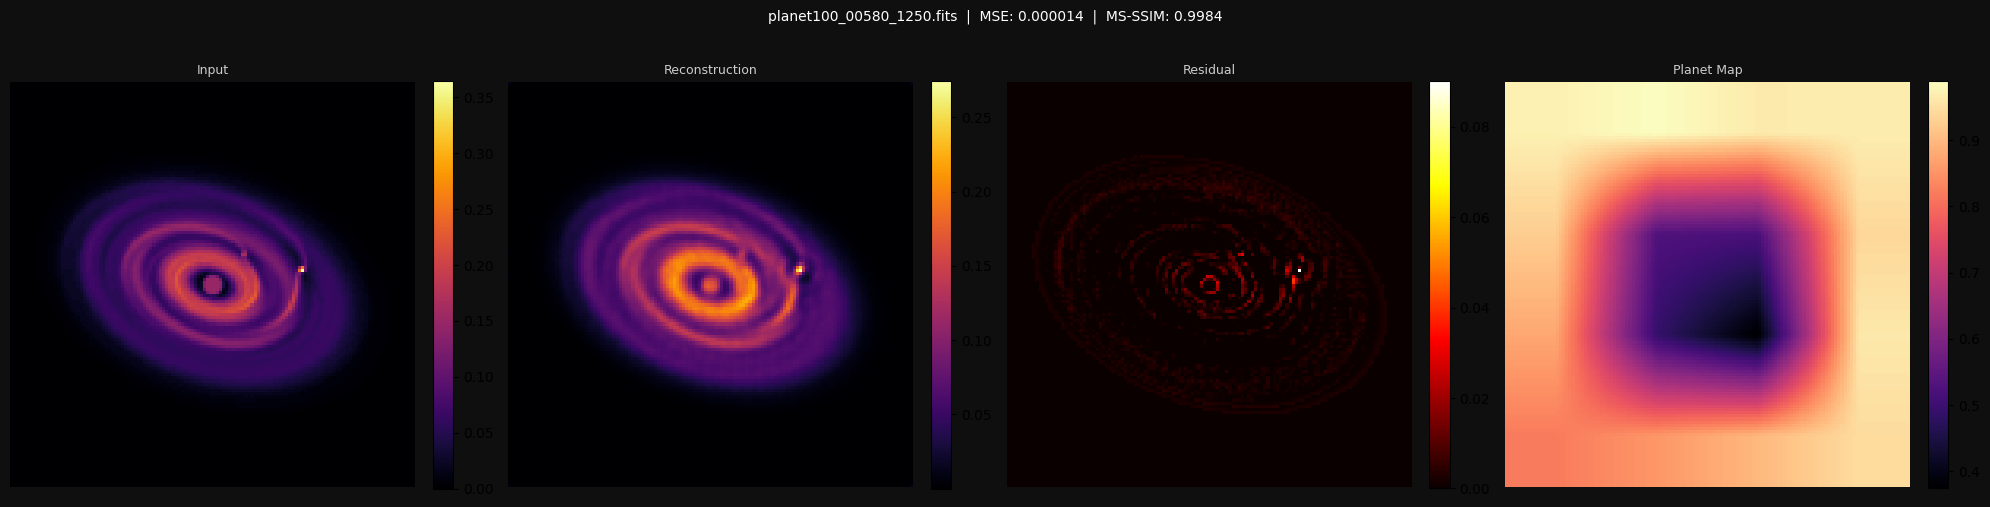

In [ ]:
idx=3
fig,axes=plt.subplots(1,4,figsize=(20,5))
fig.patch.set_facecolor('#0f0f0f')
_,imgs,_=load_fits_split([new_files[idx]])
orig=imgs[0].squeeze().numpy()
recon_img=recons[idx].squeeze().numpy()
planet_map=planet_maps[idx].squeeze().numpy()
residual=np.clip(orig-recon_img,0,None)

for ax,(data,cmap,title) in zip(axes,[
    (orig,      "inferno","Input"),
    (recon_img, "inferno","Reconstruction"),
    (residual,  "hot",    "Residual"),
    (planet_map,"magma",  "Planet Map"),
]):
    im=ax.imshow(data,cmap=cmap)
    ax.set_title(title,fontsize=9,color='#cccccc')
    ax.axis('off')
    plt.colorbar(im,ax=ax,fraction=0.046,pad=0.04)

img_mse=F.mse_loss(
    torch.tensor(recon_img).unsqueeze(0).unsqueeze(0),
    torch.tensor(orig).unsqueeze(0).unsqueeze(0)
).item()
img_msssim=ms_ssim(
    torch.tensor(recon_img).unsqueeze(0).unsqueeze(0),
    torch.tensor(orig).unsqueeze(0).unsqueeze(0),
    data_range=1.0,win_size=7
).item()
fig.suptitle(
    f"{names[idx]}  |  MSE: {img_mse:.6f}  |  MS-SSIM: {img_msssim:.4f}",
    fontsize=10,color='white',y=1.02
)
plt.tight_layout()
plt.show()

## Files Generated

| File | Description |
|---|---|
| `task2.pth` | Pre-trained DiskVAE checkpoint — model weights, optimizer state, training history, alpha values |

### Outputs available after running

| Variable | Shape | Description |
|---|---|---|
| `test_recons` | (N, 1, 128, 128) | Reconstructed test images |
| `test_planet_maps` | (N, 1, 128, 128) | Planet candidate probability maps |
| `images_train` | (N, 1, 128, 128) | Preprocessed training images |
| `images_test` | (N, 1, 128, 128) | Preprocessed test images |
| `clean_maps_train/test` | (N, 1, 128, 128) | Precomputed clean attention maps |
| `pointness_maps_train/test` | (N, 1, 128, 128) | Precomputed pointness attention maps |

After calling `run_inference()`:

| Variable | Shape | Description |
|---|---|---|
| `recons` | (N, 1, 128, 128) | Reconstructions for new images |
| `latents` | (N, 128) | Latent vectors μ for new images |
| `planet_maps` | (N, 1, 128, 128) | Planet maps for new images |